# 01 - Exploracion y limpieza del dataset crudo (.npy)

Objetivo: entender que hay en los `.npy`, cuantificar y limpiar trials segun
la calidad de marcadores, y cuadrar (parcialmente) con el paper.

**Antes de correr:** descargar el dataset del Google Drive del README y apuntar `BASE` a la raiz (`clase/sujeto/*.npy`).


In [1]:
import sys; sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import (
    load_dataset, valid_mask, masked_coords,
    analyze_gaps, interpolate_short_gaps, MARKERS,
)
from src.angles import compute_angles, ANGLE_TRIPLETS

BASE = '../data/diplegia'   # <-- cambiar al path real del dataset descargado
MAX_GAP = 5                 # frames; huecos interiores <= esto se interpolan, mas largos se descartan


## 1. Carga e inventario


In [2]:
trials = load_dataset(BASE)

rows = [{'label': t.label, 'subject': t.subject, 'trial_id': t.trial_id,
         'n_frames': t.X.shape[0]} for t in trials]
df = pd.DataFrame(rows)
print(f'Total trials: {len(df)} | pacientes unicos: {df.subject.nunique()}')
df.head()


Total trials: 1139 | pacientes unicos: 178


,label,subject,trial_id,n_frames
0,0,1,1_1,1775
1,0,1,1_2,969
2,0,1,1_3,1175
3,0,1,1_4,1243
4,0,1,1_5,1889


### Como se compara esto con el paper

Ya con el dataset cargado, vale la pena calibrar expectativas antes de seguir: el paper
reporta **174 pacientes / ~1038 trials utiles**, mientras que aca cargamos
**178 pacientes / 1139 trials crudos** (el README del dataset original), que todavia
incluyen trials con problemas de marcadores o pasos incompletos que el paper descarta.

Esa diferencia de ~100 trials **no** se explica principalmente por marcadores en mal
estado: en la seccion 5 la limpieza de marcadores descarta apenas ~10 trials de 1139.
El grueso de la diferencia viene de la **segmentacion de pasos** (etapa B, mas adelante
en el pipeline), que recorta los pasos incompletos al inicio y al final de cada trial.
Este notebook solo se ocupa de la calidad de marcadores; el recorte por pasos queda
pendiente para la etapa de features.


## 2. Distribucion por clase (comparar con Tabla 3 del paper)

Recordar el mapeo label -> forma: 0=Form I, 1=Form II, 2=Form III, 3=Form IV.


In [3]:
print('Trials por clase:'); print(df.label.value_counts().sort_index())
print('\nPacientes por clase:'); print(df.groupby('label').subject.nunique())


Trials por clase:
label
0     65
1    297
2    246
3    531
Name: count, dtype: int64

Pacientes por clase:
label
0    13
1    52
2    34
3    79
Name: subject, dtype: int64


Ratio clase mayoritaria / minoritaria: 8.2x


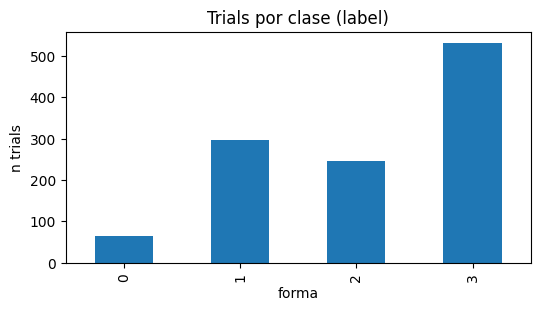

In [4]:
# Desbalance de clases: decision de modelado #1 (el paper duplica Form I con augmentation)
counts = df.label.value_counts().sort_index()
counts.plot.bar(figsize=(6,3)); plt.title('Trials por clase (label)')
plt.xlabel('forma'); plt.ylabel('n trials')
print(f'Ratio clase mayoritaria / minoritaria: {counts.max()/counts.min():.1f}x')


## 3. Validez por marcador

Vista global rapida: que marcadores fallan mas. Ojo, el promedio es engañoso
para decidir descartes (ver seccion 4).


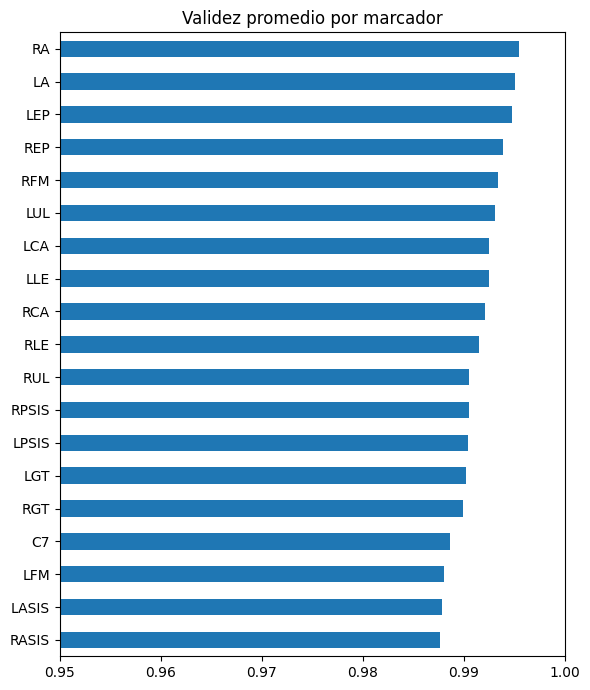

In [5]:
per_marker = np.stack([valid_mask(t.X).mean(axis=0) for t in trials])  # (n_trials, 19): fraccion de frames validos por marcador
pd.Series(per_marker.mean(axis=0), index=MARKERS).sort_values().plot.barh(figsize=(6,7))
plt.title('Validez promedio por marcador'); plt.xlim(0.95, 1.0); plt.tight_layout()


## 4. Analisis de huecos: BORDE vs INTERIOR

Un hueco (tramo de frames invalidos de un marcador) puede estar en dos lugares muy
distintos, y **donde** esta cambia por completo que significa:

- **Borde** (inicio o fin del trial): el sujeto todavia esta entrando, o ya esta
  saliendo, del volumen de captura de las camaras VICON. No es un fallo de medicion,
  es fisicamente inevitable, y ya sabemos que la segmentacion de pasos (etapa B) va a
  recortar esos frames de borde de todas formas. Un hueco de borde largo **no** implica
  un trial malo.
- **Interior** (en medio de frames validos): aqui si hubo una falla real de tracking
  mientras el sujeto caminaba dentro del volumen. Este es el que importa para decidir
  si interpolamos o descartamos (seccion 5).

`analyze_gaps(X)` devuelve `(worst_edge, worst_interior)`: el peor hueco de cada tipo,
maximo entre los 19 marcadores.


=== gap INTERIOR (decide interpolar/descartar) ===
interior >  2: 10 trials
interior >  5: 10 trials
interior > 10: 9 trials
interior > 20: 5 trials
interior > 50: 3 trials

=== bordes (los recorta la etapa B) ===
borde >  10: 162 trials
borde >  30: 101 trials
borde >  50: 79 trials
borde > 100: 61 trials


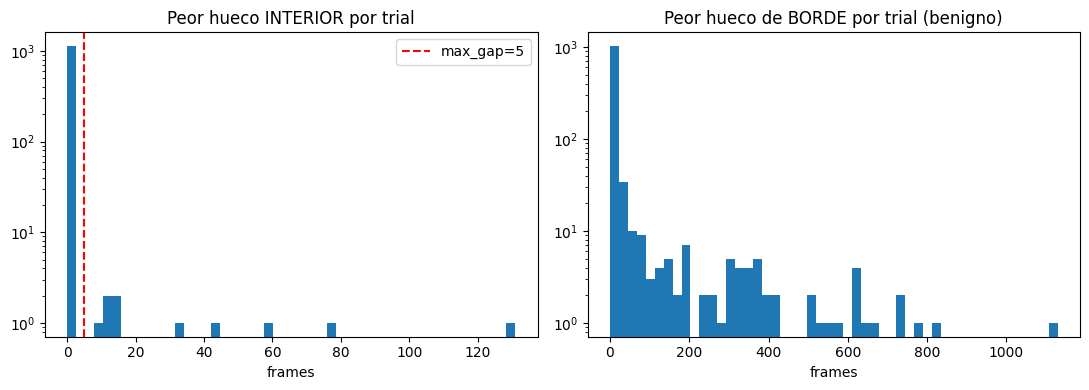

In [6]:
gaps = [analyze_gaps(t.X) for t in trials]
edge     = np.array([e for e, _ in gaps])
interior = np.array([i for _, i in gaps])

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].hist(interior, bins=50); ax[0].set_yscale('log')
ax[0].axvline(MAX_GAP, color='r', ls='--', label=f'max_gap={MAX_GAP}')
ax[0].set_title('Peor hueco INTERIOR por trial'); ax[0].set_xlabel('frames'); ax[0].legend()
ax[1].hist(edge, bins=50); ax[1].set_yscale('log')
ax[1].set_title('Peor hueco de BORDE por trial (benigno)'); ax[1].set_xlabel('frames')
plt.tight_layout()

print('=== gap INTERIOR (decide interpolar/descartar) ===')
for g in [2, 5, 10, 20, 50]:
    print(f'interior > {g:>2}: {(interior > g).sum()} trials')
print('\n=== bordes (los recorta la etapa B) ===')
for g in [10, 30, 50, 100]:
    print(f'borde > {g:>3}: {(edge > g).sum()} trials')


## 5. Limpieza: interpolar huecos cortos, descartar los de hueco interior largo

Interpolamos los huecos interiores cortos (<= `MAX_GAP` = 5 frames, 50 ms a 100 fps)
porque la marcha es un movimiento continuo: en una ventana tan corta el marcador no
puede moverse de forma impredecible, asi que una linea recta entre los dos puntos
validos que bracketean el hueco es una estimacion razonable.

Descartamos el trial cuando el hueco interior es largo (> `MAX_GAP`) porque ahi la
interpolacion lineal deja de ser fiel al movimiento real (puede haber una transicion
de swing/stance en el medio) y fabricar esa trayectoria contaminaria los angulos y la
FFT con señal inventada. Es un criterio conservador y barato: afecta a ~10 de 1139 trials.

Los bordes (seccion 4) quedan fuera de esta decision porque no son una falla de
marcador, sino el sujeto entrando/saliendo del volumen de captura.

Orden: **interpolar primero, filtrar despues**, asi un trial con solo huecos cortos
se salva. `interpolate_short_gaps` no muta el original; aca reasignamos `t.X` para
dejar `trials` limpio de aqui en adelante.


In [7]:
usable_trials, total_filled = [], 0
filled_log = []  # trazabilidad clinica: que se fabrico y donde
for t in trials:
    t.X, filled = interpolate_short_gaps(t.X, max_gap=MAX_GAP)
    if filled:
        filled_log.append({'trial': t.trial_id, 'label': t.label, **filled})
    total_filled += sum(filled.values())
    _, worst_interior = analyze_gaps(t.X)
    if worst_interior <= MAX_GAP:
        usable_trials.append(t)

print(f'Trials no usables (gap interior > {MAX_GAP}): {len(trials) - len(usable_trials)}')
print(f'Trials usables: {len(usable_trials)} de {len(trials)}')
print(f'Frames interpolados en total: {total_filled}')
pd.DataFrame(filled_log)


Trials no usables (gap interior > 5): 10
Trials usables: 1129 de 1139
Frames interpolados en total: 199


,trial,label,RGT,LASIS,LPSIS,RUL,LGT,C7,LEP,RCA,LLE,LUL,RASIS,RPSIS,LCA,RFM,LFM
0,12_5,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20_1,1,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22_1,1,17.0,NaN,NaN,9.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25_1,1,NaN,NaN,NaN,3.0,NaN,6.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25_4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
5,34_3,1,5.0,NaN,2.0,4.0,1.0,NaN,5.0,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN
6,56_1,1,6.0,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,5.0,8.0,5.0,NaN
7,69_8,2,NaN,3.0,2.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN
8,79_1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
9,109_1,3,NaN,NaN,5.0,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,5.0,NaN


In [8]:
# Conjunto limpio para las siguientes etapas
clean = usable_trials
clean_df = pd.DataFrame([{'label': t.label, 'subject': t.subject} for t in clean])
print(f'Dataset limpio: {len(clean)} trials, {clean_df.subject.nunique()} pacientes')
print('Trials por clase (limpio):'); print(clean_df.label.value_counts().sort_index())


Dataset limpio: 1129 trials, 178 pacientes
Trials por clase (limpio):
label
0     64
1    293
2    245
3    527
Name: count, dtype: int64


## 6. Sanity check de angulos

Verificar que los 27 angulos de la Tabla 5 se calculan sobre un trial limpio.


shape angulos: (1775, 27) (frames x 27)


Text(0, 0.5, 'grados')

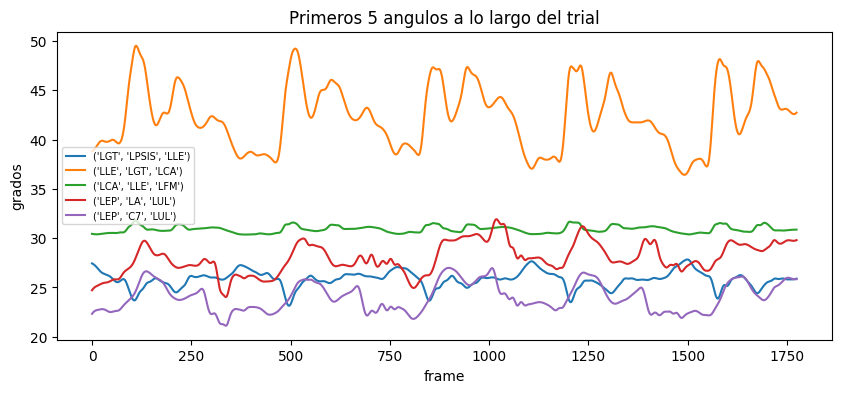

In [9]:
ang = compute_angles(masked_coords(clean[0].X))
print('shape angulos:', ang.shape, '(frames x 27)')
plt.figure(figsize=(10,4))
plt.plot(ang[:, :5]); plt.legend([str(t) for t in ANGLE_TRIPLETS[:5]], fontsize=7)
plt.title('Primeros 5 angulos a lo largo del trial'); plt.xlabel('frame'); plt.ylabel('grados')
